# Predictor performance swarm plot

Aggregate standardized single- and multi-predictor TRF result tables, verify that their controlled experiment settings match, and plot each subject's held-out EEG prediction performance. Colored points are subjects; black diamonds and error bars show the group mean and 95% confidence interval.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in (cwd, *cwd.parents)
        if (path / 'analysis' / 'trf_pipeline' / 'results' / 'by_predictor').exists()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError('Could not locate the Alice project root')

trf_pipeline_dir = repo_root / 'analysis' / 'trf_pipeline'
result_roots = {
    'single_predictor': trf_pipeline_dir / 'results' / 'by_predictor',
    'multi_predictor': trf_pipeline_dir / 'results' / 'by_multi_predictor',
}
aggregate_path = (
    trf_pipeline_dir / 'results' / 'aggregate' / 'predictor_subject_results_long.csv'
)
figure_path = repo_root / 'figures' / 'trf_predictor_swarmplot.png'

# False: primary QC rows only (default); True: all successful finite TRFs.
INCLUDE_EXCLUDED = False

In [13]:
RESULT_FILENAME = 'subject_results.csv'
METRIC = 'tracking_r_mean'
REQUIRED_COLUMNS = {
    'subject',
    'experiment_id',
    'predictor',
    'estimator',
    'raw',
    'epoch',
    'reference',
    'inv',
    'tstart',
    'tstop',
    'samplingrate',
    'filter_x',
    'status',
    'finite_result',
    'include_trf_primary',
    METRIC,
}
CONTROLLED_COLUMNS = (
    'estimator',
    'raw',
    'epoch',
    'reference',
    'inv',
    'tstart',
    'tstop',
    'samplingrate',
    'filter_x',
)
PREFERRED_PREDICTOR_ORDER = (
    'gammatone-8',
    'gammatone-1',
    'gammatone-on-8',
    'gammatone-on-1',
    'gammatone-8 + gammatone-on-8',
    'gammatone-1 + gammatone-on-1',
)


def load_model_results(result_roots):
    tables = []
    subject_sets = {}
    for model_type, results_root in result_roots.items():
        paths = sorted(results_root.glob(f'*/{RESULT_FILENAME}'))
        for path in paths:
            table = pd.read_csv(path, keep_default_na=False)
            missing = REQUIRED_COLUMNS - set(table.columns)
            if missing:
                raise ValueError(f'{path} is missing columns: {sorted(missing)}')

            experiment_ids = table['experiment_id'].unique().tolist()
            model_terms = table['predictor'].unique().tolist()
            if len(experiment_ids) != 1 or len(model_terms) != 1:
                raise ValueError(
                    f'{path} must contain one experiment/model; found '
                    f'experiment_id={experiment_ids}, predictor={model_terms}'
                )
            experiment_id = experiment_ids[0]
            model_term = model_terms[0]
            if experiment_id != path.parent.name:
                raise ValueError(
                    f'Experiment {experiment_id!r} does not match directory '
                    f'{path.parent.name!r}'
                )
            if table['subject'].duplicated().any():
                duplicates = table.loc[
                    table['subject'].duplicated(), 'subject'
                ].tolist()
                raise ValueError(f'{path} contains duplicate subjects: {duplicates}')

            table = table.copy()
            table['model_type'] = model_type
            table['model_term'] = model_term
            table['source_file'] = str(path)
            tables.append(table)
            subject_sets[experiment_id] = set(table['subject'])

    if not tables:
        raise FileNotFoundError(
            f'No {RESULT_FILENAME!r} files found under {list(result_roots.values())}'
        )

    reference_predictor = next(iter(subject_sets))
    reference_subjects = subject_sets[reference_predictor]
    mismatched_subjects = {
        experiment_id: sorted(subjects.symmetric_difference(reference_subjects))
        for experiment_id, subjects in subject_sets.items()
        if subjects != reference_subjects
    }
    if mismatched_subjects:
        raise ValueError(
            'Predictor tables do not contain the same subjects: '
            f'{mismatched_subjects}'
        )

    aggregate = pd.concat(tables, ignore_index=True)
    for column in CONTROLLED_COLUMNS:
        values = aggregate[column].unique().tolist()
        if len(values) != 1:
            raise ValueError(
                f'Controlled setting {column!r} differs across results: {values}'
            )

    duplicate_keys = aggregate.duplicated(['subject', 'experiment_id'])
    if duplicate_keys.any():
        duplicates = aggregate.loc[
            duplicate_keys, ['subject', 'experiment_id']
        ].to_dict('records')
        raise ValueError(f'Duplicate subject-predictor rows: {duplicates}')

    aggregate[METRIC] = pd.to_numeric(aggregate[METRIC], errors='raise')
    return aggregate


def predictor_order(aggregate):
    available = aggregate['predictor'].unique().tolist()
    preferred = [
        name for name in PREFERRED_PREDICTOR_ORDER if name in available
    ]
    remaining = sorted(set(available) - set(preferred))
    return preferred + remaining

In [14]:
aggregate = load_model_results(result_roots)
order = predictor_order(aggregate)

comparison_summary = (
    aggregate.groupby('predictor', observed=True)
    .agg(
        n_subjects=('subject', 'nunique'),
        n_primary=('include_trf_primary', 'sum'),
        mean_tracking_r=(METRIC, 'mean'),
        median_tracking_r=(METRIC, 'median'),
    )
    .reindex(order)
)
comparison_summary

,n_subjects,n_primary,mean_tracking_r,median_tracking_r
predictor,,,,
gammatone-8,49,47,0.030342,0.027020
gammatone-1,49,47,0.029867,0.027520
gammatone-on-8,49,47,0.020852,0.019128
gammatone-on-1,49,47,0.018063,0.015480
gammatone-8 + gammatone-on-8,49,47,0.031753,0.028459
gammatone-1 + gammatone-on-1,49,47,0.031568,0.029208


In [15]:
aggregate_path.parent.mkdir(parents=True, exist_ok=True)
aggregate.to_csv(aggregate_path, index=False)
aggregate_path

PosixPath('/Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/analysis/trf_pipeline/results/aggregate/predictor_subject_results_long.csv')

Plotted 282 rows from 47 subjects
Saved aggregate table: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/analysis/trf_pipeline/results/aggregate/predictor_subject_results_long.csv
Saved figure: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/figures/trf_predictor_swarmplot.png
Saved figure: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/figures/trf_predictor_swarmplot.pdf


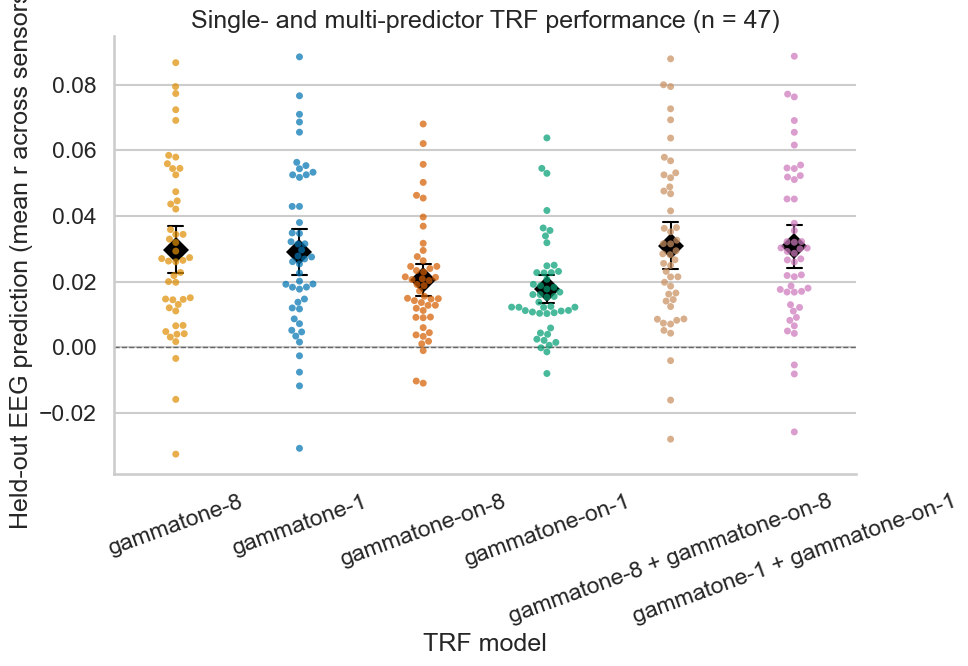

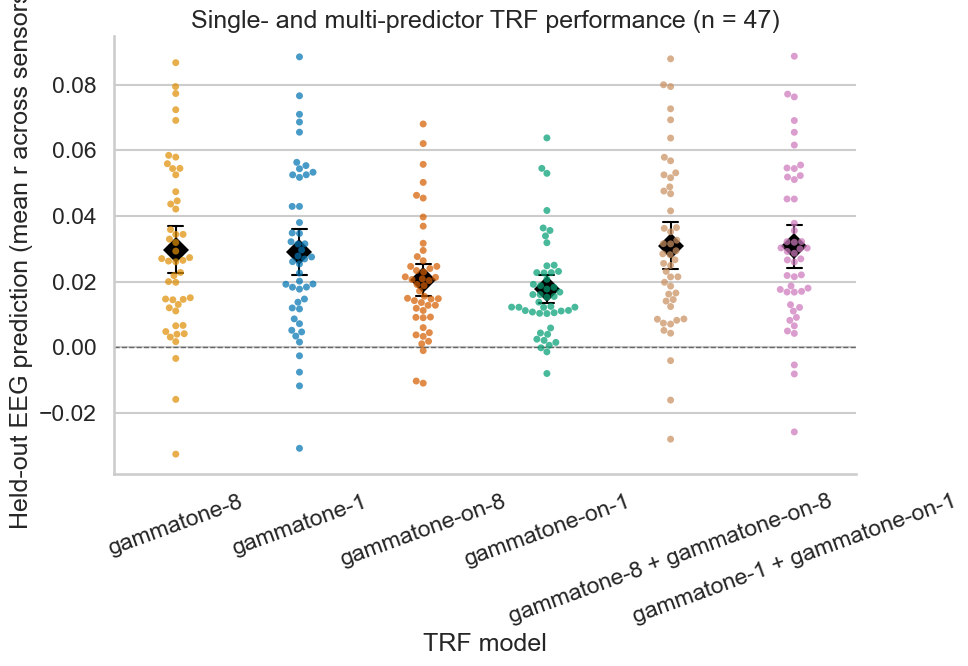

In [16]:
if INCLUDE_EXCLUDED:
    plot_data = aggregate.loc[
        aggregate['status'].eq('ok') & aggregate['finite_result']
    ].copy()
else:
    plot_data = aggregate.loc[aggregate['include_trf_primary']].copy()

if plot_data.empty:
    raise ValueError('No rows remain after applying plot inclusion criteria')

order = predictor_order(plot_data)
counts = plot_data.groupby('predictor', observed=True)['subject'].nunique()
if counts.nunique() != 1:
    raise ValueError(
        'Predictors have unequal plotted subject counts after QC: '
        f'{counts.to_dict()}'
    )

sns.set_theme(style='whitegrid', context='talk')
figure, axis = plt.subplots(figsize=(10, 7))

sns.swarmplot(
    data=plot_data,
    x='predictor',
    y=METRIC,
    order=order,
    hue='predictor',
    palette='colorblind',
    legend=False,
    size=5,
    alpha=0.72,
    ax=axis,
)
sns.pointplot(
    data=plot_data,
    x='predictor',
    y=METRIC,
    order=order,
    estimator='mean',
    errorbar=('ci', 95),
    seed=0,
    color='black',
    markers='D',
    linestyles='none',
    capsize=0.12,
    err_kws={'linewidth': 1.5},
    ax=axis,
)

n_subjects = int(counts.iloc[0])
axis.axhline(0, color='0.4', linestyle='--', linewidth=1)
axis.set_title(f'Single- and multi-predictor TRF performance (n = {n_subjects})')
axis.set_xlabel('TRF model')
axis.set_ylabel('Held-out EEG prediction (mean r across sensors)')
axis.tick_params(axis='x', rotation=20)
sns.despine(ax=axis)
figure.tight_layout()

figure_path.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(figure_path, dpi=300, bbox_inches='tight')
figure.savefig(figure_path.with_suffix('.pdf'), bbox_inches='tight')
print(f'Plotted {len(plot_data)} rows from {n_subjects} subjects')
print(f'Saved aggregate table: {aggregate_path}')
print(f'Saved figure: {figure_path}')
print(f"Saved figure: {figure_path.with_suffix('.pdf')}")
figure